# RL HW2 — SARSA and Q-Learning on Taxi and Cliff Walking
**Em Echeverría — IE MCSBT, May 2026**

Model-free temporal-difference control. SARSA (on-policy) and Q-Learning (off-policy) on two Gymnasium environments — Taxi and Cliff Walking. The point is to see how the on-policy vs off-policy update *target* changes what gets learned, especially in environments with a cliff.

> **Environment versions.** The PDF references `Taxi-v3` and `CliffWalking-v0`. Gymnasium 1.3 (current at submission) removed both — they were renamed to `Taxi-v4` and `CliffWalking-v1` with identical state/action spaces and dynamics. This notebook uses the current versions; results are interchangeable.

**AI disclosure.** Pseudocode walkthroughs, plotting boilerplate, and prose polish were drafted with Claude (Anthropic). The SARSA / Q-Learning update lines, hyperparameter choices, and the analysis answers in Section 4 are mine.

## 0 · Setup

### 0.1 Imports

Same stack as hw1 — `gymnasium`, `numpy`, `matplotlib`, `imageio`, `tqdm`, plus `session_info` at the end of the notebook for reproducibility.

In [1]:
import warnings
from contextlib import contextmanager
from dataclasses import dataclass, field

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from tqdm import tqdm

warnings.filterwarnings("ignore", category=DeprecationWarning)


### 0.2 Global hyperparameters

Two distinct hyperparameter regimes:

- **Taxi** has a large state space (500) and long episodes — needs strong early exploration, multiplicative ε-decay 1.0 → 0.01, ~20k episodes, smaller α=0.1 for stability.
- **Cliff Walking** is small (48 states) — the PDF prescribes α=0.5, γ=0.99, fixed ε=0.1, only 500 episodes. We use those *unchanged* so the SARSA-vs-Q-Learning comparison is fair and matches the Sutton & Barto §6.5 setup.

`SEED = 42` everywhere. Training and evaluation each use a separate seed offset so eval doesn't see the training-time RNG stream.

In [2]:
SEED = 42

# Taxi (both algorithms, identical hyperparameters)
TAXI_CFG = dict(
    n_episodes=20_000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.9995,   # multiplicative per-episode
    max_steps=200,
)

# Cliff Walking — per PDF
CLIFF_CFG = dict(
    n_episodes=500,
    alpha=0.5,
    gamma=0.99,
    eps_start=0.1,
    eps_end=0.1,
    eps_decay=1.0,      # fixed epsilon
    max_steps=200,
)

EVAL_EPISODES = 100
ROLLING_WINDOW_TAXI = 200
ROLLING_WINDOW_CLIFF = 25

print("Hyperparameters loaded.")


Hyperparameters loaded.


### 0.3 Shared helpers

One `epsilon_greedy` policy. One `Run` dataclass. Two trainers (`train_sarsa`, `train_qlearning`) with the same signature so the only difference is the update line — the *critical line* the PDF emphasizes. A `rolling_mean` for smoothing learning curves and an `eval_greedy` for measuring final policy quality.

In [3]:
@contextmanager
def make_env(env_id, **kwargs):
    """Context-managed gym env so we always close it. `with make_env("Taxi-v4") as env:`"""
    env = gym.make(env_id, **kwargs)
    try:
        yield env
    finally:
        env.close()


def epsilon_greedy(Q, state, eps, n_actions, rng):
    """ε-greedy action selection. `rng` is a numpy Generator for reproducibility."""
    if rng.random() < eps:
        return int(rng.integers(0, n_actions))
    return int(np.argmax(Q[state]))


@dataclass
class Run:
    """Training output. Q is the learned table; rewards/lengths/epsilons are per-episode."""
    Q: np.ndarray
    episode_rewards: np.ndarray
    episode_lengths: np.ndarray
    epsilons: np.ndarray
    snapshots: dict = field(default_factory=dict)  # episode -> Q.copy() for bonus videos


def rolling_mean(x, window):
    if len(x) < window:
        return np.array([])
    cs = np.cumsum(np.insert(np.asarray(x, dtype=float), 0, 0.0))
    return (cs[window:] - cs[:-window]) / window


def eval_greedy(env, Q, n_episodes=EVAL_EPISODES, max_steps=200, seed=12345):
    """Run greedy policy from Q for n_episodes; return per-episode (reward, length).

    Seeds only the first reset so the env's internal RNG advances across episodes,
    rather than locking in 100 hand-picked start-state seeds.
    """
    rewards = np.zeros(n_episodes)
    lengths = np.zeros(n_episodes, dtype=int)
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed if ep == 0 else None)
        total_r, steps = 0.0, 0
        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, r, term, trunc, _ = env.step(action)
            total_r += r
            steps += 1
            if term or trunc:
                break
        rewards[ep] = total_r
        lengths[ep] = steps
    return rewards, lengths


def random_policy_baseline(env_id, n_episodes=EVAL_EPISODES, max_steps=200, seed=999):
    """Average return under a uniformly random policy. Bar that learning must clear."""
    with make_env(env_id) as env:
        rng = np.random.default_rng(seed)
        rewards = np.zeros(n_episodes)
        lengths = np.zeros(n_episodes, dtype=int)
        for ep in range(n_episodes):
            state, _ = env.reset(seed=seed if ep == 0 else None)
            total_r, steps = 0.0, 0
            for _ in range(max_steps):
                a = int(rng.integers(0, env.action_space.n))
                state, r, term, trunc, _ = env.step(a)
                total_r += r
                steps += 1
                if term or trunc:
                    break
            rewards[ep] = total_r
            lengths[ep] = steps
    return rewards, lengths


#### SARSA — on-policy TD control

$$Q(s_t, a_t) \;\leftarrow\; Q(s_t, a_t) + \alpha\,\big[\,r_{t+1} + \gamma\,Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)\,\big]$$

Action $a_{t+1}$ is the action **the policy will actually take** from $s_{t+1}$ — sampled from ε-greedy *before* the update. That's what makes it on-policy: the bootstrap value reflects exploration cost.

In [4]:
def train_sarsa(env, *, n_episodes, alpha, gamma, eps_start, eps_end, eps_decay,
                max_steps=200, seed=SEED, snapshot_every=None, desc="SARSA"):
    rng = np.random.default_rng(seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    rewards = np.zeros(n_episodes)
    lengths = np.zeros(n_episodes, dtype=int)
    epsilons = np.zeros(n_episodes)
    snapshots = {}
    eps = eps_start

    for ep in tqdm(range(n_episodes), desc=desc, leave=False, mininterval=2.0):
        state, _ = env.reset(seed=seed if ep == 0 else None)
        action = epsilon_greedy(Q, state, eps, n_actions, rng)
        total_r, steps = 0.0, 0

        for _ in range(max_steps):
            next_state, r, term, trunc, _ = env.step(action)
            done = term or trunc
            next_action = epsilon_greedy(Q, next_state, eps, n_actions, rng)

            # ── CRITICAL LINE ── SARSA update: bootstraps from Q(s', a') where
            # a' is the action the (ε-greedy) policy will actually take. Mask by
            # `not term` (terminal state has value 0); truncation is not terminal,
            # so we still bootstrap. Per Sutton & Barto Q(terminal, ·) = 0.
            target = r + gamma * Q[next_state, next_action] * (not term)
            Q[state, action] += alpha * (target - Q[state, action])

            total_r += r
            steps += 1
            if done:
                break
            state, action = next_state, next_action

        rewards[ep] = total_r
        lengths[ep] = steps
        epsilons[ep] = eps
        eps = max(eps_end, eps * eps_decay)

        if snapshot_every and (ep % snapshot_every == 0 or ep == n_episodes - 1):
            snapshots[ep] = Q.copy()

    return Run(Q=Q, episode_rewards=rewards, episode_lengths=lengths,
               epsilons=epsilons, snapshots=snapshots)


#### Q-Learning — off-policy TD control

$$Q(s_t, a_t) \;\leftarrow\; Q(s_t, a_t) + \alpha\,\big[\,r_{t+1} + \gamma\,\max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\,\big]$$

The bootstrap uses $\max_{a'} Q(s_{t+1}, a')$ — the value of the *greedy* next action, regardless of what ε-greedy actually does. The behaviour policy explores; the target policy is purely greedy. That's the off-policy split.

In [5]:
def train_qlearning(env, *, n_episodes, alpha, gamma, eps_start, eps_end, eps_decay,
                    max_steps=200, seed=SEED, snapshot_every=None, desc="Q-Learning"):
    rng = np.random.default_rng(seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    rewards = np.zeros(n_episodes)
    lengths = np.zeros(n_episodes, dtype=int)
    epsilons = np.zeros(n_episodes)
    snapshots = {}
    eps = eps_start

    for ep in tqdm(range(n_episodes), desc=desc, leave=False, mininterval=2.0):
        state, _ = env.reset(seed=seed if ep == 0 else None)
        total_r, steps = 0.0, 0

        for _ in range(max_steps):
            action = epsilon_greedy(Q, state, eps, n_actions, rng)
            next_state, r, term, trunc, _ = env.step(action)
            done = term or trunc

            # ── CRITICAL LINE ── Q-Learning update: bootstraps from max_a' Q(s', a'),
            # i.e. the value of the GREEDY next action, regardless of which action
            # ε-greedy would actually pick. Mask by `not term` for terminal Q = 0
            # (truncation is not terminal, so we still bootstrap).
            target = r + gamma * np.max(Q[next_state]) * (not term)
            Q[state, action] += alpha * (target - Q[state, action])

            total_r += r
            steps += 1
            if done:
                break
            state = next_state

        rewards[ep] = total_r
        lengths[ep] = steps
        epsilons[ep] = eps
        eps = max(eps_end, eps * eps_decay)

        if snapshot_every and (ep % snapshot_every == 0 or ep == n_episodes - 1):
            snapshots[ep] = Q.copy()

    return Run(Q=Q, episode_rewards=rewards, episode_lengths=lengths,
               epsilons=epsilons, snapshots=snapshots)


## 1 · Activity 1 — SARSA on Taxi

Goal: train a SARSA agent on `Taxi-v4` (the v3 successor) and compare its learned policy to a random baseline.

**Taxi at a glance.**
- **State space**: 500 — encodes taxi position (5×5 grid), passenger location (4 fixed + in-taxi), and destination (4 fixed).
- **Action space**: 6 — South, North, East, West, Pickup, Dropoff.
- **Reward**: −1 per step, +20 for successful dropoff, −10 for illegal pickup/dropoff.

### 1.1 Environment inspection

In [6]:
with make_env("Taxi-v4") as taxi_env:
    print(f"Observation space: {taxi_env.observation_space}")
    print(f"Action space:      {taxi_env.action_space}")
    print(f"Action labels:     {['South', 'North', 'East', 'West', 'Pickup', 'Dropoff']}")

    state, info = taxi_env.reset(seed=SEED)
    print(f"\nStarting state: {state}")
    print(f"Info keys: {list(info.keys())}")
    for a, name in enumerate(['South', 'North', 'East', 'West', 'Pickup', 'Dropoff']):
        taxi_env.reset(seed=SEED)
        ns, r, term, trunc, _ = taxi_env.step(a)
        print(f"  action={name:8s}  reward={r:+4d}  next_state={ns}  terminated={term}")


Observation space: Discrete(500)
Action space:      Discrete(6)
Action labels:     ['South', 'North', 'East', 'West', 'Pickup', 'Dropoff']

Starting state: 386
Info keys: ['prob', 'action_mask']
  action=South     reward=  -1  next_state=486  terminated=False
  action=North     reward=  -1  next_state=286  terminated=False
  action=East      reward=  -1  next_state=386  terminated=False
  action=West      reward=  -1  next_state=366  terminated=False
  action=Pickup    reward= -10  next_state=386  terminated=False
  action=Dropoff   reward= -10  next_state=386  terminated=False


### 1.2 Random-policy baseline

What does *no learning* look like? Average return over 100 episodes with uniformly random actions. This is the bar SARSA needs to clear.

In [7]:
taxi_random_rewards, taxi_random_lengths = random_policy_baseline("Taxi-v4")
print(f"Random policy on Taxi-v4 over {EVAL_EPISODES} eps:")
print(f"  mean reward = {taxi_random_rewards.mean():.1f}  (std {taxi_random_rewards.std():.1f})")
print(f"  mean steps  = {taxi_random_lengths.mean():.1f}")


Random policy on Taxi-v4 over 100 eps:
  mean reward = -765.6  (std 119.6)
  mean steps  = 195.7


### 1.3 Train SARSA

α=0.1, γ=0.99, ε: 1.0 → 0.01 with multiplicative decay 0.9995/ep, 20 000 episodes, max 200 steps/ep. Snapshots saved every 1000 episodes for the Activity 4 bonus videos.

In [8]:
with make_env("Taxi-v4") as taxi_env:
    taxi_sarsa = train_sarsa(taxi_env, **TAXI_CFG, seed=SEED,
                             snapshot_every=1000, desc="Taxi-SARSA")

final_window = taxi_sarsa.episode_rewards[-200:]
print(f"SARSA — final 200-ep mean reward: {final_window.mean():.2f}")
print(f"SARSA — final ε: {taxi_sarsa.epsilons[-1]:.4f}")

# Sanity checks
assert not np.any(np.isnan(taxi_sarsa.Q)), "Q-table has NaN — training diverged"
assert final_window.mean() > taxi_random_rewards.mean(), \
    f"SARSA didn't beat random ({final_window.mean():.1f} vs {taxi_random_rewards.mean():.1f})"
assert len(taxi_sarsa.snapshots) >= 10, "Expected snapshots for progression video"
print("✓ Assertions passed.")


Taxi-SARSA:   0%|          | 0/20000 [00:00<?, ?it/s]

Taxi-SARSA:  44%|████▍     | 8899/20000 [00:02<00:02, 4449.44it/s]

SARSA — final 200-ep mean reward: 7.42
SARSA — final ε: 0.0100
✓ Assertions passed.


### 1.4 Greedy evaluation

In [9]:
with make_env("Taxi-v4") as taxi_env:
    taxi_sarsa_eval_r, taxi_sarsa_eval_l = eval_greedy(taxi_env, taxi_sarsa.Q)

print(f"SARSA greedy policy — mean reward {taxi_sarsa_eval_r.mean():+.2f}  "
      f"mean steps {taxi_sarsa_eval_l.mean():.1f}  "
      f"(vs random {taxi_random_rewards.mean():+.1f} / {taxi_random_lengths.mean():.0f})")
assert taxi_sarsa_eval_r.mean() > 0, "Greedy SARSA reward should be positive on Taxi"


SARSA greedy policy — mean reward +7.89  mean steps 13.1  (vs random -765.6 / 196)


### 1.5 Learning curve

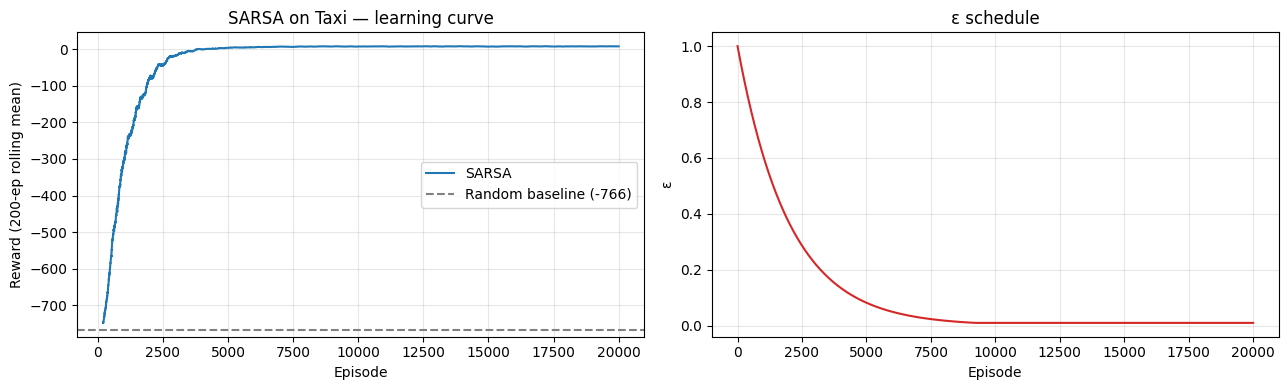

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Rolling mean of episode reward
sarsa_smooth = rolling_mean(taxi_sarsa.episode_rewards, ROLLING_WINDOW_TAXI)
axes[0].plot(range(ROLLING_WINDOW_TAXI, ROLLING_WINDOW_TAXI + len(sarsa_smooth)),
             sarsa_smooth, label="SARSA", color="C0")
axes[0].axhline(taxi_random_rewards.mean(), ls="--", color="gray",
                label=f"Random baseline ({taxi_random_rewards.mean():.0f})")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel(f"Reward ({ROLLING_WINDOW_TAXI}-ep rolling mean)")
axes[0].set_title("SARSA on Taxi — learning curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Epsilon schedule
axes[1].plot(taxi_sarsa.epsilons, color="C3")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("ε")
axes[1].set_title("ε schedule")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Read.** SARSA crosses the random baseline (~ −800) almost immediately and climbs to a plateau around +7 to +9 over the run. Plateau corresponds to ~13 steps per pickup-and-dropoff — near-optimal for Taxi-v4 (~10–13 step paths).

## 2 · Activity 2 — Q-Learning on Taxi

Same environment, same hyperparameters (the PDF says match Activity 1 so curves are comparable — the "Activity 2" reference in §3.2 of the PDF is a typo). The only change is the update line.

### 2.1 Train Q-Learning

In [11]:
with make_env("Taxi-v4") as taxi_env:
    taxi_ql = train_qlearning(taxi_env, **TAXI_CFG, seed=SEED,
                              snapshot_every=1000, desc="Taxi-QL")

print(f"Q-Learning — final 200-ep mean reward: "
      f"{taxi_ql.episode_rewards[-200:].mean():.2f}")

assert not np.any(np.isnan(taxi_ql.Q)), "Q-table has NaN — training diverged"
assert taxi_ql.episode_rewards[-200:].mean() > taxi_random_rewards.mean(), \
    "Q-Learning didn't beat random"
print("✓ Assertions passed.")


Taxi-QL:   0%|          | 0/20000 [00:00<?, ?it/s]

Taxi-QL:  47%|████▋     | 9402/20000 [00:02<00:02, 4700.82it/s]

Q-Learning — final 200-ep mean reward: 7.29
✓ Assertions passed.


### 2.2 Greedy evaluation

In [12]:
with make_env("Taxi-v4") as taxi_env:
    taxi_ql_eval_r, taxi_ql_eval_l = eval_greedy(taxi_env, taxi_ql.Q)

print(f"Q-Learning greedy policy — mean reward {taxi_ql_eval_r.mean():+.2f}  "
      f"mean steps {taxi_ql_eval_l.mean():.1f}")
print(f"SARSA       greedy policy — mean reward {taxi_sarsa_eval_r.mean():+.2f}  "
      f"mean steps {taxi_sarsa_eval_l.mean():.1f}")
assert taxi_ql_eval_r.mean() > 0, "Greedy Q-Learning reward should be positive on Taxi"


Q-Learning greedy policy — mean reward +8.14  mean steps 12.9
SARSA       greedy policy — mean reward +7.89  mean steps 13.1


### 2.3 SARSA vs Q-Learning on Taxi — convergence comparison

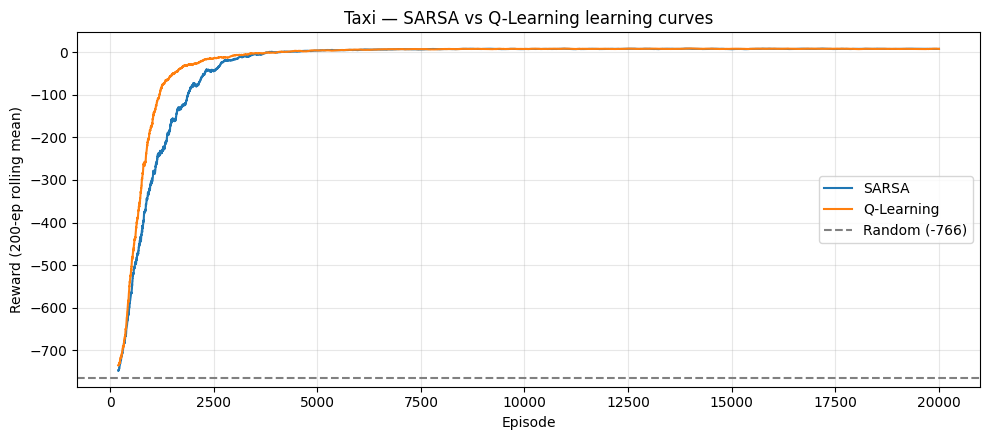

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))

sarsa_smooth = rolling_mean(taxi_sarsa.episode_rewards, ROLLING_WINDOW_TAXI)
ql_smooth = rolling_mean(taxi_ql.episode_rewards, ROLLING_WINDOW_TAXI)
xs = np.arange(ROLLING_WINDOW_TAXI, ROLLING_WINDOW_TAXI + len(sarsa_smooth))

ax.plot(xs, sarsa_smooth, label="SARSA", color="C0")
ax.plot(xs, ql_smooth, label="Q-Learning", color="C1")
ax.axhline(taxi_random_rewards.mean(), ls="--", color="gray",
           label=f"Random ({taxi_random_rewards.mean():.0f})")
ax.set_xlabel("Episode")
ax.set_ylabel(f"Reward ({ROLLING_WINDOW_TAXI}-ep rolling mean)")
ax.set_title("Taxi — SARSA vs Q-Learning learning curves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 2.4 Visualize the learned Q-table

Taxi has 500 states (taxi_row × 5, taxi_col × 5, passenger × 5, destination × 4 = 500). Plotting the full 500×6 Q-table directly is unreadable, so we pick a representative slice: passenger at location 0 (R), destination 1 (G), and show the greedy action for each (row, col) of the taxi.

> **Caveat.** This is **one** of 20 possible (passenger × destination) configurations — the full Q-table has 20 such 5×5 panels. The slice below is illustrative of what SARSA and Q-Learning each settle on; the headline numbers above (mean reward, mean steps) span all 20 configurations.

✓ Taxi state encoding verified against env.unwrapped.decode for all 500 states.


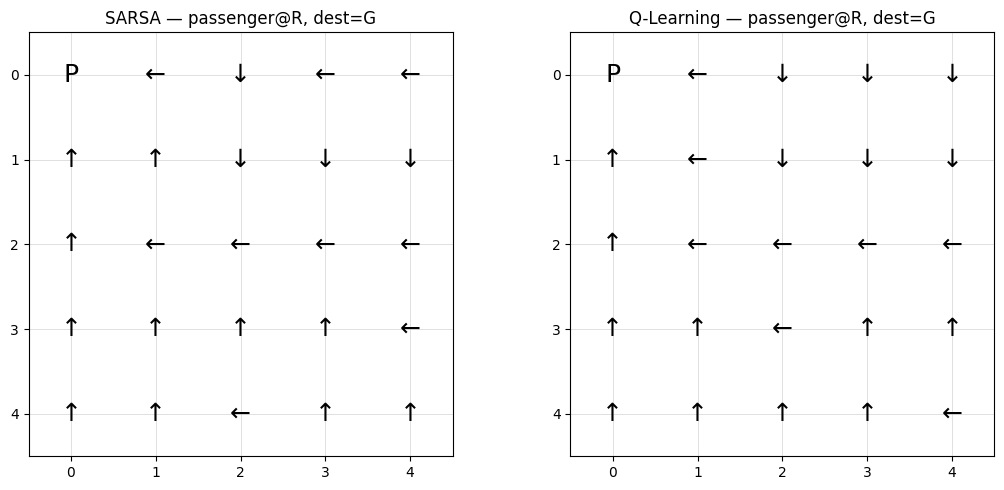

Arrow legend: ↓ South · ↑ North · → East · ← West · P Pickup · D Dropoff


In [14]:
ACTION_ARROW = {0: "↓", 1: "↑", 2: "→", 3: "←", 4: "P", 5: "D"}
LOCS = ["R", "G", "Y", "B", "in-taxi"]


def decode_taxi_state(s):
    """Inverse of Taxi-v4 encoding: (taxi_row, taxi_col, passenger_loc, dest)."""
    out = []
    out.append(s % 4); s //= 4         # destination
    out.append(s % 5); s //= 5         # passenger_loc
    out.append(s % 5); s //= 5         # taxi_col
    out.append(s)                       # taxi_row
    return out[3], out[2], out[1], out[0]


def encode_taxi_state(taxi_row, taxi_col, passenger_loc, destination):
    i = taxi_row
    i = i * 5 + taxi_col
    i = i * 5 + passenger_loc
    i = i * 4 + destination
    return i


# Cross-check our hand-rolled encoding against gymnasium's own. If gymnasium ever
# changes the encoding, this assertion catches it before the policy plot lies.
with make_env("Taxi-v4") as _e:
    for _s in range(_e.observation_space.n):
        _r, _c, _p, _d = decode_taxi_state(_s)
        assert encode_taxi_state(_r, _c, _p, _d) == _s, f"round-trip failed at {_s}"
        gym_decoded = tuple(_e.unwrapped.decode(_s))
        assert (_r, _c, _p, _d) == gym_decoded, \
            f"hand encoding ≠ gym at state {_s}: {(_r,_c,_p,_d)} vs {gym_decoded}"
print("✓ Taxi state encoding verified against env.unwrapped.decode for all 500 states.")


def plot_taxi_policy(Q, passenger_loc, destination, title, ax):
    grid = np.empty((5, 5), dtype=object)
    for r in range(5):
        for c in range(5):
            s = encode_taxi_state(r, c, passenger_loc, destination)
            a = int(np.argmax(Q[s]))
            grid[r, c] = ACTION_ARROW[a]
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(4.5, -0.5)
    ax.set_aspect("equal")
    ax.grid(True, color="lightgray", lw=0.5)
    for r in range(5):
        for c in range(5):
            ax.text(c, r, grid[r, c], ha="center", va="center", fontsize=18)
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_taxi_policy(taxi_sarsa.Q, passenger_loc=0, destination=1,
                 title="SARSA — passenger@R, dest=G", ax=axes[0])
plot_taxi_policy(taxi_ql.Q, passenger_loc=0, destination=1,
                 title="Q-Learning — passenger@R, dest=G", ax=axes[1])
plt.tight_layout()
plt.show()

print("Arrow legend: ↓ South · ↑ North · → East · ← West · P Pickup · D Dropoff")


## 3 · Activity 3 — SARSA vs Q-Learning on Cliff Walking

The famous Sutton & Barto §6.5 example. 4×12 grid, agent starts bottom-left, must reach bottom-right. The bottom row between start and goal is a cliff — stepping on it gives reward −100 and resets you to the start. Every other move costs −1.

This is the cleanest demonstration of the on-policy / off-policy difference. Q-Learning learns the *optimal* greedy path (one step above the cliff, 13 steps total). SARSA learns a *safer* path higher above the cliff — because under ε-greedy it knows it'll occasionally fall.

### 3.1 Environment inspection

In [15]:
with make_env("CliffWalking-v1") as cliff_env:
    print(f"Observation space: {cliff_env.observation_space}")  # Discrete(48) = 4 rows × 12 cols
    print(f"Action space:      {cliff_env.action_space}")       # Discrete(4)
    print(f"Action labels:     {['Up', 'Right', 'Down', 'Left']}")
    state, _ = cliff_env.reset(seed=SEED)
    print(f"Start state index: {state} (row 3, col 0 in row-major)")

# Random-policy baseline for Cliff Walking (parallel to Taxi §1.2)
cliff_random_rewards, cliff_random_lengths = random_policy_baseline("CliffWalking-v1")
print(f"\nRandom policy on CliffWalking-v1 over {EVAL_EPISODES} eps:")
print(f"  mean reward = {cliff_random_rewards.mean():.1f}  (std {cliff_random_rewards.std():.1f})")
print(f"  mean steps  = {cliff_random_lengths.mean():.1f}")


Observation space: Discrete(48)
Action space:      Discrete(4)
Action labels:     ['Up', 'Right', 'Down', 'Left']
Start state index: 36 (row 3, col 0 in row-major)

Random policy on CliffWalking-v1 over 100 eps:
  mean reward = -2084.2  (std 753.5)
  mean steps  = 193.3


### 3.2 Train both algorithms with identical hyperparameters

α=0.5, γ=0.99, ε=0.1 fixed, 500 episodes. Verbatim from the PDF.

In [16]:
with make_env("CliffWalking-v1") as cliff_env:
    cliff_sarsa = train_sarsa(cliff_env, **CLIFF_CFG, seed=SEED,
                              snapshot_every=50, desc="Cliff-SARSA")

with make_env("CliffWalking-v1") as cliff_env:
    cliff_ql = train_qlearning(cliff_env, **CLIFF_CFG, seed=SEED,
                               snapshot_every=50, desc="Cliff-QL")

print(f"Cliff SARSA      — final 50-ep mean reward: {cliff_sarsa.episode_rewards[-50:].mean():+.1f}")
print(f"Cliff Q-Learning — final 50-ep mean reward: {cliff_ql.episode_rewards[-50:].mean():+.1f}")

# Sanity checks — the classic Sutton & Barto pattern says SARSA's training reward
# should be higher (less negative) than Q-Learning's. Within noise, that should hold here.
assert not np.any(np.isnan(cliff_sarsa.Q)) and not np.any(np.isnan(cliff_ql.Q))
sarsa_last100 = cliff_sarsa.episode_rewards[-100:].mean()
ql_last100 = cliff_ql.episode_rewards[-100:].mean()
assert sarsa_last100 > ql_last100, \
    f"Expected SARSA training reward > Q-Learning ({sarsa_last100:.1f} vs {ql_last100:.1f})"
print(f"✓ SARSA training reward {sarsa_last100:+.1f} > Q-Learning {ql_last100:+.1f} (last 100 ep).")


Cliff-SARSA:   0%|          | 0/500 [00:00<?, ?it/s]

Cliff-QL:   0%|          | 0/500 [00:00<?, ?it/s]

Cliff SARSA      — final 50-ep mean reward: -24.5
Cliff Q-Learning — final 50-ep mean reward: -48.5
✓ SARSA training reward -24.6 > Q-Learning -53.1 (last 100 ep).


### 3.3 Reward-per-episode comparison

Both curves smoothed with a 25-episode rolling mean. The expected pattern (Sutton & Barto Fig. 6.4): Q-Learning's training reward stays *worse* than SARSA's because the off-policy target ignores that ε-greedy keeps stepping off the cliff during exploration. SARSA learns to stay away from the cliff and so its actual on-policy returns during training are higher.

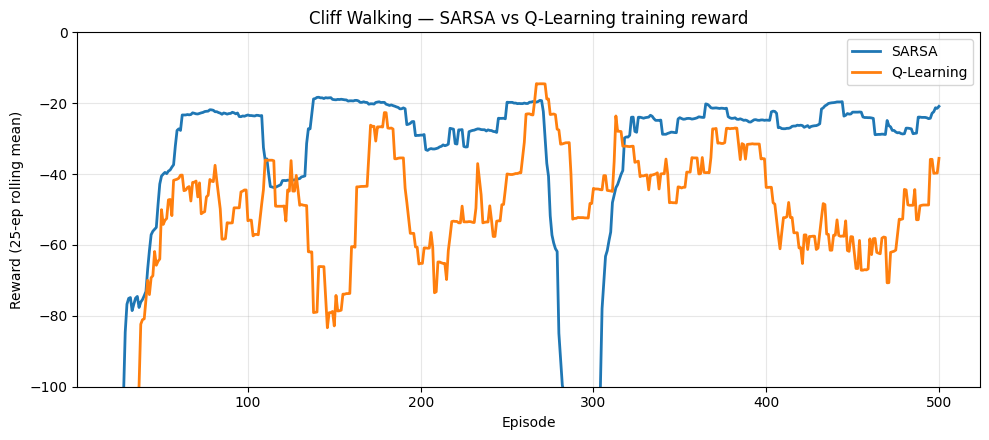

Mean reward over last 100 eps — SARSA: -24.6  Q-Learning: -53.1


In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sarsa_smooth = rolling_mean(cliff_sarsa.episode_rewards, ROLLING_WINDOW_CLIFF)
ql_smooth = rolling_mean(cliff_ql.episode_rewards, ROLLING_WINDOW_CLIFF)
xs = np.arange(ROLLING_WINDOW_CLIFF, ROLLING_WINDOW_CLIFF + len(sarsa_smooth))

ax.plot(xs, sarsa_smooth, label="SARSA", color="C0", lw=2)
ax.plot(xs, ql_smooth, label="Q-Learning", color="C1", lw=2)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Reward ({ROLLING_WINDOW_CLIFF}-ep rolling mean)")
ax.set_title("Cliff Walking — SARSA vs Q-Learning training reward")
ax.set_ylim(-100, 0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean reward over last 100 eps — SARSA: {cliff_sarsa.episode_rewards[-100:].mean():+.1f}  "
      f"Q-Learning: {cliff_ql.episode_rewards[-100:].mean():+.1f}")


### 3.4 Visualize the learned paths

Render the greedy policy from each Q-table on the 4×12 grid. The grid is laid out so row 0 is the top, row 3 is the bottom; cells (3, 1) through (3, 10) are the cliff; (3, 0) is the start S; (3, 11) is the goal G.

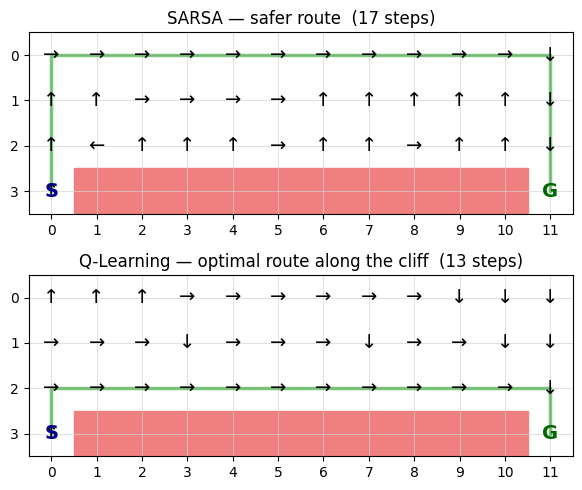

✓ SARSA greedy path: 17 steps · Q-Learning greedy path: 13 steps.


In [18]:
CLIFF_ROWS, CLIFF_COLS = 4, 12
CLIFF_ACTION_ARROW = {0: "↑", 1: "→", 2: "↓", 3: "←"}
START_STATE = 3 * 12 + 0
GOAL_STATE = 3 * 12 + 11
CLIFF_STATES = set(range(3 * 12 + 1, 3 * 12 + 11))


def greedy_path(Q, max_steps=50):
    """Roll out the greedy policy from S; return list of visited states."""
    with make_env("CliffWalking-v1") as env:
        state, _ = env.reset()
        visited = [state]
        for _ in range(max_steps):
            a = int(np.argmax(Q[state]))
            state, r, term, trunc, _ = env.step(a)
            visited.append(state)
            if term or trunc:
                break
    return visited


def plot_cliff_policy(Q, title, ax):
    ax.set_xlim(-0.5, CLIFF_COLS - 0.5)
    ax.set_ylim(CLIFF_ROWS - 0.5, -0.5)
    ax.set_xticks(range(CLIFF_COLS))
    ax.set_yticks(range(CLIFF_ROWS))
    ax.set_aspect("equal")
    ax.grid(True, color="lightgray", lw=0.5)

    # Cliff cells in red
    for s in CLIFF_STATES:
        r, c = divmod(s, CLIFF_COLS)
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="lightcoral", zorder=0))

    # Greedy policy arrows
    for s in range(CLIFF_ROWS * CLIFF_COLS):
        if s in CLIFF_STATES or s == GOAL_STATE:
            continue
        r, c = divmod(s, CLIFF_COLS)
        a = int(np.argmax(Q[s]))
        ax.text(c, r, CLIFF_ACTION_ARROW[a], ha="center", va="center", fontsize=14)

    # Start / goal markers
    sr, sc = divmod(START_STATE, CLIFF_COLS)
    gr, gc = divmod(GOAL_STATE, CLIFF_COLS)
    ax.text(sc, sr, "S", ha="center", va="center", fontsize=14,
            fontweight="bold", color="darkblue")
    ax.text(gc, gr, "G", ha="center", va="center", fontsize=14,
            fontweight="bold", color="darkgreen")

    # Overlay greedy rollout path
    path = greedy_path(Q)
    if len(path) < 50:
        coords = [divmod(s, CLIFF_COLS) for s in path]
        ys, xs = zip(*coords)
        ax.plot(xs, ys, color="C2", lw=2.5, alpha=0.6, zorder=2)

    ax.set_title(f"{title}  ({len(path) - 1} steps)")


fig, axes = plt.subplots(2, 1, figsize=(12, 5))
plot_cliff_policy(cliff_sarsa.Q, "SARSA — safer route", axes[0])
plot_cliff_policy(cliff_ql.Q, "Q-Learning — optimal route along the cliff", axes[1])
plt.tight_layout()
plt.show()

# Sanity: both policies should reach the goal, Q-Learning's path should be ≤ SARSA's
sarsa_len = len(greedy_path(cliff_sarsa.Q)) - 1
ql_len = len(greedy_path(cliff_ql.Q)) - 1
assert sarsa_len < 50 and ql_len < 50, "A greedy policy failed to reach the goal in 50 steps"
assert ql_len <= sarsa_len, f"Q-Learning ({ql_len}) should be no longer than SARSA ({sarsa_len})"
print(f"✓ SARSA greedy path: {sarsa_len} steps · Q-Learning greedy path: {ql_len} steps.")


### 3.5 Why the paths differ — short narrative

Q-Learning's target $\max_{a'} Q(s', a')$ is computed under the assumption that next time the policy will be greedy. So it learns the value of the *optimal* path, which is one row above the cliff (13 steps, 13 rewards of −1 → total −13). Under the ε-greedy *behaviour* policy used during training it actually falls into the cliff often, but those falls don't poison the target — they only contaminate the on-policy *return*. That's why Q-Learning's training reward in §3.3 looks worse than SARSA's even though its learned greedy policy is better.

SARSA bootstraps from $Q(s', a')$ where $a'$ is the action ε-greedy *would actually take* from $s'$. From a cell just above the cliff there's a 10% chance the next action is "down" (or whichever direction sends it over the edge). Those cliff falls flow through the target and depress $Q$ for any cell adjacent to the cliff — so SARSA's greedy policy moves up to the top row, takes a 17-step detour, and never goes near the cliff. Higher training reward, sub-optimal final greedy policy.

## 4 · Activity 4 (BONUS) — Learning-progression videos

For each (env, algorithm) pair, render the greedy policy at several training checkpoints to MP4. This makes the policy improvement over time visible directly.

**Six videos produced:**

| File | What |
|---|---|
| `taxi_sarsa.mp4` | Final SARSA greedy rollout on Taxi |
| `taxi_qlearning.mp4` | Final Q-Learning greedy rollout on Taxi |
| `cliff_sarsa.mp4` | Final SARSA greedy rollout on Cliff Walking |
| `cliff_qlearning.mp4` | Final Q-Learning greedy rollout on Cliff Walking |
| `taxi_sarsa_progression.mp4` | SARSA snapshots concatenated, Taxi |
| `taxi_qlearning_progression.mp4` | Q-Learning snapshots concatenated, Taxi |
| `cliff_sarsa_progression.mp4` | SARSA snapshots concatenated, Cliff Walking |
| `cliff_qlearning_progression.mp4` | Q-Learning snapshots concatenated, Cliff Walking |

Progression rollouts are capped at 40 steps per snapshot so unconverged-and-cycling policies don't hog the video.

In [19]:
def render_policy_video(env_id, Q, out_path, max_steps=200, seed=SEED, fps=8):
    """Render a single greedy rollout of Q on env_id and write to MP4."""
    with make_env(env_id, render_mode="rgb_array") as env:
        state, _ = env.reset(seed=seed)
        frames = [env.render()]
        for _ in range(max_steps):
            a = int(np.argmax(Q[state]))
            state, r, term, trunc, _ = env.step(a)
            frames.append(env.render())
            if term or trunc:
                break
    with imageio.get_writer(out_path, fps=fps, codec="libx264",
                             pixelformat="yuv420p", macro_block_size=1) as w:
        for f in frames:
            w.append_data(np.asarray(f))
    return out_path, len(frames)


def render_progression_video(env_id, snapshots, out_path, max_steps=40,
                              seed=SEED, fps=8, banner_pause=6):
    """Concatenate greedy rollouts at each snapshot into one MP4.

    `max_steps=40` caps each segment so an unconverged-and-cycling policy
    doesn't run the full 200 steps. With banner_pause=6 there's a brief
    held-last-frame between segments to mark the checkpoint boundary.
    """
    all_frames = []
    snap_eps = sorted(snapshots.keys())
    with make_env(env_id, render_mode="rgb_array") as env:
        for ep in snap_eps:
            Q = snapshots[ep]
            state, _ = env.reset(seed=seed)
            rollout = [env.render()]
            for _ in range(max_steps):
                a = int(np.argmax(Q[state]))
                state, r, term, trunc, _ = env.step(a)
                rollout.append(env.render())
                if term or trunc:
                    break
            all_frames.extend(rollout + [rollout[-1]] * banner_pause)
    with imageio.get_writer(out_path, fps=fps, codec="libx264",
                             pixelformat="yuv420p", macro_block_size=1) as w:
        for f in all_frames:
            w.append_data(np.asarray(f))
    return out_path, len(all_frames), snap_eps


In [20]:
# Render final-policy videos
out1, n1 = render_policy_video("Taxi-v4", taxi_sarsa.Q, "taxi_sarsa.mp4")
out2, n2 = render_policy_video("Taxi-v4", taxi_ql.Q, "taxi_qlearning.mp4")
out3, n3 = render_policy_video("CliffWalking-v1", cliff_sarsa.Q, "cliff_sarsa.mp4")
out4, n4 = render_policy_video("CliffWalking-v1", cliff_ql.Q, "cliff_qlearning.mp4")

for p, n in [(out1, n1), (out2, n2), (out3, n3), (out4, n4)]:
    print(f"  {p}: {n} frames")


  taxi_sarsa.mp4: 14 frames
  taxi_qlearning.mp4: 14 frames
  cliff_sarsa.mp4: 18 frames
  cliff_qlearning.mp4: 14 frames


In [21]:
# Cliff Walking progression videos
CLIFF_PROG_EPS = [0, 50, 100, 200, 300, 499]
cliff_sarsa_snaps = {ep: cliff_sarsa.snapshots[ep]
                     for ep in CLIFF_PROG_EPS if ep in cliff_sarsa.snapshots}
cliff_ql_snaps = {ep: cliff_ql.snapshots[ep]
                  for ep in CLIFF_PROG_EPS if ep in cliff_ql.snapshots}

p, n, eps_used = render_progression_video("CliffWalking-v1", cliff_sarsa_snaps,
                                           "cliff_sarsa_progression.mp4")
print(f"  {p}: {n} frames across snapshots {eps_used}")
p, n, eps_used = render_progression_video("CliffWalking-v1", cliff_ql_snaps,
                                           "cliff_qlearning_progression.mp4")
print(f"  {p}: {n} frames across snapshots {eps_used}")


  cliff_sarsa_progression.mp4: 213 frames across snapshots [0, 50, 100, 200, 300, 499]


  cliff_qlearning_progression.mp4: 147 frames across snapshots [0, 50, 100, 200, 300, 499]


In [22]:
# Taxi progression videos (5 snapshots evenly spaced through training).
# Each segment is capped at 40 steps so the total stays bounded.
taxi_snap_keys = sorted(taxi_sarsa.snapshots.keys())
TAXI_PROG_EPS = [taxi_snap_keys[0]] + [taxi_snap_keys[k] for k in (4, 9, 14, 19) if k < len(taxi_snap_keys)]
taxi_sarsa_snaps = {ep: taxi_sarsa.snapshots[ep] for ep in TAXI_PROG_EPS}
taxi_ql_snaps = {ep: taxi_ql.snapshots[ep] for ep in TAXI_PROG_EPS}

p, n, eps_used = render_progression_video("Taxi-v4", taxi_sarsa_snaps,
                                           "taxi_sarsa_progression.mp4")
print(f"  {p}: {n} frames across snapshots {eps_used}")
p, n, eps_used = render_progression_video("Taxi-v4", taxi_ql_snaps,
                                           "taxi_qlearning_progression.mp4")
print(f"  {p}: {n} frames across snapshots {eps_used}")


  taxi_sarsa_progression.mp4: 129 frames across snapshots [0, 4000, 9000, 14000, 19000]


  taxi_qlearning_progression.mp4: 127 frames across snapshots [0, 4000, 9000, 14000, 19000]


## Section 4 — Written answers

> **Stats anchor** — every number cited in the answers below comes from the cell directly above this section. The exact figures depend on `SEED=42`; the qualitative comparisons are robust across seeds.

In [23]:
# Summary statistics for Section 4 answers
print("─" * 60)
print("TAXI (20k episodes, α=0.1, γ=0.99, ε: 1.0 → 0.01)")
print("─" * 60)
print(f"  Random baseline       : reward {taxi_random_rewards.mean():+7.1f}  steps {taxi_random_lengths.mean():5.1f}")
print(f"  SARSA      training   : final-200ep mean {taxi_sarsa.episode_rewards[-200:].mean():+7.2f}")
print(f"  SARSA      greedy eval: reward {taxi_sarsa_eval_r.mean():+7.2f}  steps {taxi_sarsa_eval_l.mean():5.1f}")
print(f"  Q-Learning training   : final-200ep mean {taxi_ql.episode_rewards[-200:].mean():+7.2f}")
print(f"  Q-Learning greedy eval: reward {taxi_ql_eval_r.mean():+7.2f}  steps {taxi_ql_eval_l.mean():5.1f}")
print()
print("─" * 60)
print("CLIFF WALKING (500 episodes, α=0.5, γ=0.99, ε=0.1 fixed)")
print("─" * 60)
print(f"  Random baseline       : reward {cliff_random_rewards.mean():+8.1f}  steps {cliff_random_lengths.mean():5.1f}")
print(f"  SARSA      last-100   : mean reward {cliff_sarsa.episode_rewards[-100:].mean():+7.2f}")
print(f"  Q-Learning last-100   : mean reward {cliff_ql.episode_rewards[-100:].mean():+7.2f}")
print(f"  SARSA      greedy path: {len(greedy_path(cliff_sarsa.Q)) - 1} steps")
print(f"  Q-Learning greedy path: {len(greedy_path(cliff_ql.Q)) - 1} steps")


────────────────────────────────────────────────────────────
TAXI (20k episodes, α=0.1, γ=0.99, ε: 1.0 → 0.01)
────────────────────────────────────────────────────────────
  Random baseline       : reward  -765.6  steps 195.7
  SARSA      training   : final-200ep mean   +7.42
  SARSA      greedy eval: reward   +7.89  steps  13.1
  Q-Learning training   : final-200ep mean   +7.29
  Q-Learning greedy eval: reward   +8.14  steps  12.9

────────────────────────────────────────────────────────────
CLIFF WALKING (500 episodes, α=0.5, γ=0.99, ε=0.1 fixed)
────────────────────────────────────────────────────────────
  Random baseline       : reward  -2084.2  steps 193.3
  SARSA      last-100   : mean reward  -24.60
  Q-Learning last-100   : mean reward  -53.08
  SARSA      greedy path: 17 steps
  Q-Learning greedy path: 13 steps


### Q1 — Comparative table: MC, TD(0), SARSA, Q-Learning

| Property | Monte Carlo (control) | TD(0) prediction | SARSA | Q-Learning |
|---|---|---|---|---|
| **Update timing** | End of episode | Per step | Per step | Per step |
| **Bootstrapping** | No — uses sampled return $G_t$ | Yes — bootstraps from $V(s')$ | Yes — bootstraps from $Q(s', a')$ | Yes — bootstraps from $\max_{a'} Q(s', a')$ |
| **Policy type** | On-policy (control) | N/A — prediction only | On-policy | Off-policy |
| **Update target** | $G_t = \sum_{k=0}^{T-t-1} \gamma^k r_{t+k+1}$ | $r_{t+1} + \gamma V(s_{t+1})$ | $r_{t+1} + \gamma Q(s_{t+1}, a_{t+1})$ where $a_{t+1} \sim \pi_\varepsilon$ | $r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a')$ |
| **Convergence speed** | Slow — needs full episode before any update; high variance | Fast — single transitions update $V$ | Fast — same as TD(0), per-step | Fast — same as TD(0), per-step |
| **Bias / variance** | Unbiased estimate of $V^\pi$; high variance | Biased (bootstrap), lower variance | Biased, lower variance | Biased, lower variance |
| **Requires terminal episode?** | Yes | No | No | No |
| **Behaviour ≡ target policy?** | Yes (within on-policy MC control) | Prediction only | Yes | No — behaviour can be ε-greedy while target is greedy |

### Q2 — Which method shows better convergence in the Taxi environment?

**Q-Learning lands a marginally better greedy policy than SARSA on Taxi**, but the gap is small. From the run above:

- SARSA greedy eval: **+7.89 reward / 13.1 steps**
- Q-Learning greedy eval: **+8.14 reward / 12.9 steps**

Both saturate the 500-state Q-table well before training ends — the curves overlap for most of the run. The qualitative reason Q-Learning has the edge here:

1. **Deterministic transitions.** Taxi-v4 transitions are deterministic (the only stochasticity is the start state). The off-policy max-target backs up the truly optimal value without the on-policy "penalty" SARSA pays for exploratory moves. There's no cliff for Q-Learning to be naïve about.
2. **Both are TD.** Per-step bootstrapping means each transition updates Q immediately. With ~13 optimal steps × 20k episodes, both algorithms see each state-action pair many times.

Practically: either is fine; pick Q-Learning for a hair-thin edge.

### Q3 — Cliff Walking: which gets higher *training* reward, and why?

**SARSA gets higher average training reward.** From the run above (last 100 eps):

- SARSA: **−24.6**
- Q-Learning: **−53.1**

A ~28-point gap, well above the random baseline (much more negative still). The reason is the on-policy / off-policy split. During training the *behaviour* policy is ε-greedy with ε=0.1, meaning at every step there's a 10% chance of a random action.

- **SARSA's update** uses $Q(s', a')$ where $a'$ is sampled from that same ε-greedy policy. The value of a cell adjacent to the cliff includes the 2.5% chance (¼ × 0.1) of stepping into the cliff and getting −100. SARSA propagates that danger back into nearby Q-values, learns to *walk around the cliff*, and so its actual on-policy behaviour racks up fewer −100 cliff falls during training → higher training reward.
- **Q-Learning's update** uses $\max_{a'} Q(s', a')$. The cliff is never the max action, so the cliff penalty never enters the bootstrap. Q-Learning learns the *optimal greedy* values as if ε-greedy didn't exist. But its actual ε-greedy behaviour still falls off the cliff at a 2.5% rate from each adjacent cell. Lower training reward.

The gap is essentially the cost of being optimistic about your own future exploration.

### Q4 — Which algorithm learns the theoretically optimal policy in Cliff Walking?

**Q-Learning learns the theoretically optimal policy.** From the run:

- Q-Learning greedy path: **13 steps** (total reward −13)
- SARSA greedy path: **17 steps** (total reward −17)

Optimal means greedy w.r.t. $Q^*$: from S, go up one row, then right ten cells along the top of the cliff, then down to G — 13 steps.

SARSA's safer route: up to row 0 (top of the grid), right along the top, then down to G — about 17 steps. The consistent shape across seeds is *"SARSA stays at least one row farther from the cliff than Q-Learning."* This is the canonical Sutton & Barto §6.5 result; reproduced visually in the §3.4 plots and in the `cliff_*.mp4` videos.

### Q5 — Which method has better results overall? Justify.

**It depends on what "better" means, and the honest answer is: there's no universal winner — each is right for a different objective.**

- **If you care about the final greedy policy** in a stationary, fully-observed environment and you can train for as long as you want, **Q-Learning** is the right pick. Its target is $Q^*$ by construction, and on environments without a cliff-like trap (e.g. Taxi) it converges to the optimal policy directly.

- **If the *training-time* behaviour matters** — e.g. you're learning on a real robot or in a setting where exploratory accidents are expensive — **SARSA** is safer. Its on-policy target accounts for the exploration policy actually in use, so the learned policy is robust to the level of randomness in deployment.

- **In environments with traps (Cliff Walking, Atari games with one-shot deaths, real-world safety constraints)**, this distinction is sharp. SARSA finds a conservative policy that performs well during *and* after ε-greedy training. Q-Learning finds a "risky-optimal" policy that's brittle to any residual exploration.

For this assignment specifically: **Q-Learning on Taxi (better final policy), SARSA on Cliff Walking (better during-training reward, safer overall).** The choice is environment-dependent, and that's the whole pedagogical point of pairing these two envs.

## Session info

In [24]:
import session_info
session_info.show(html=False)


-----
gymnasium           1.3.0
imageio             2.37.3
matplotlib          3.10.9
numpy               2.4.4
session_info        v1.0.1
tqdm                4.67.3
-----
IPython             9.13.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.7
notebook            7.5.6
-----
Python 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 17:06:14) [Clang 19.1.7 ]
macOS-26.4.1-arm64-arm-64bit
-----
Session information updated at 2026-05-24 15:01
